# Setup

In [20]:
import os
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
# Function to load in the files
def load_data(n_bikes, n_drones):
    bike_frames = []
    drone_frames = []

    for i in range(1, n_bikes + 1):
        bike_file = f"../logs/bike/bike_{i}.csv"
        if os.path.exists(bike_file):
            bike_df = pd.read_csv(bike_file, skipinitialspace=True)
            bike_df.insert(loc=0, column="ID", value=i)
            bike_frames.append(bike_df)

    for i in range(1, n_drones + 1):
        drone_file = f"../logs/drone/drone_{i}.csv"
        if os.path.exists(drone_file):
            drone_df = pd.read_csv(drone_file, skipinitialspace=True)
            drone_df.insert(loc=0, column="ID", value=i)
            drone_frames.append(drone_df)

    bike_data = pd.concat(bike_frames, ignore_index=True) if bike_frames else pd.DataFrame()
    drone_data = pd.concat(drone_frames, ignore_index=True) if drone_frames else pd.DataFrame()

    return bike_data, drone_data

In [22]:
def add_nearby_drones(bike_data, drone_data, radius=50):
    bike_data = bike_data.copy()

    bike_data["nearby_drones"] = 0
    bike_data["min_distance"] = 0

    for i, bike in bike_data.iterrows():
        count = 0
        min_distance = float('inf')

        same_time_drones = drone_data[drone_data["Timestep"] == bike["Timestep"]]

        for _, drone in same_time_drones.iterrows():
            if (
                abs(bike["Pos x"] - drone["Pos x"]) <= radius and
                abs(bike["Pos y"] - drone["Pos y"]) <= radius and
                abs(bike["Pos z"] - drone["Pos z"]) <= radius
            ):
                count += 1
            distance = math.sqrt(pow(bike["Pos x"] - drone["Pos x"], 2) + pow(bike["Pos y"] - drone["Pos y"], 2) + pow(bike["Pos z"] - drone["Pos z"], 2))
            min_distance = min(min_distance, distance)
        
        bike_data.at[i, "min_distance"] = min_distance
        bike_data.at[i, "nearby_drones"] = count

    return bike_data

In [23]:
def add_nearby_bikes(bike_data, drone_data, radius=50):
    drone_data = drone_data.copy()

    drone_data["nearby_bikes"] = 0
    drone_data["min_distance"] = 0

    for i, drone in drone_data.iterrows():
        count = 0
        min_distance = float('inf')

        same_time_bikes = bike_data[bike_data["Timestep"] == drone["Timestep"]]

        for _, bike in same_time_bikes.iterrows():
            if (
                abs(drone["Pos x"] - bike["Pos x"]) <= radius and
                abs(drone["Pos y"] - bike["Pos y"]) <= radius and
                abs(drone["Pos z"] - bike["Pos z"]) <= radius
            ):
                count += 1

            distance = math.sqrt(pow(bike["Pos x"] - drone["Pos x"], 2) + pow(bike["Pos y"] - drone["Pos y"], 2) + pow(bike["Pos z"] - drone["Pos z"], 2))
            min_distance = min(min_distance, distance)

        drone_data.at[i, "min_distance"] = min_distance
        drone_data.at[i, "nearby_bikes"] = count

    return drone_data

In [24]:
def setup(n_bikes, n_drones):
    bike_data, drone_data = load_data(n_bikes, n_drones)
    bike_data = add_nearby_drones(bike_data, drone_data)
    drone_data = add_nearby_bikes(bike_data, drone_data)
    
    return bike_data, drone_data

#### Change amount of drones and bikes below to fit the numbers on the run


In [25]:
n_bikes = 5
n_drones = 5

bike_data, drone_data = setup(n_bikes, n_drones)

#Save to csv for later use
bike_data.to_csv("data/bike_data.csv", index=False)
drone_data.to_csv("data/drone_data.csv", index=False)



/var/folders/3d/bsb4syvd7jbf6_yltgmslcy40000gn/T/ipykernel_20198/980380897.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '5.312905207564905' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  bike_data.at[i, "min_distance"] = min_distance
/var/folders/3d/bsb4syvd7jbf6_yltgmslcy40000gn/T/ipykernel_20198/872085079.py:24: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '5.312905207564905' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  drone_data.at[i, "min_distance"] = min_distance


# Plot data

#### Average distance from drone to nearest bike

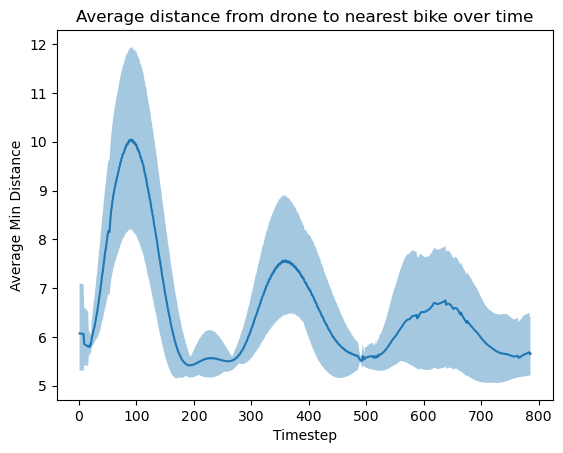

In [62]:
df = pd.read_csv("data/drone_data.csv")
avg_dist = df.groupby("Timestep")["min_distance"].agg(["mean", "min", "max"]).reset_index()

sns.lineplot(data=avg_dist, x="Timestep", y="mean")

plt.fill_between(
    avg_dist["Timestep"],
    avg_dist["min"],
    avg_dist["max"],
    alpha=0.4
)

plt.title("Average distance from drone to nearest bike over time")
plt.xlabel("Timestep")
plt.ylabel("Average Min Distance")
plt.show()

#### Average distance from bike to nearest drone

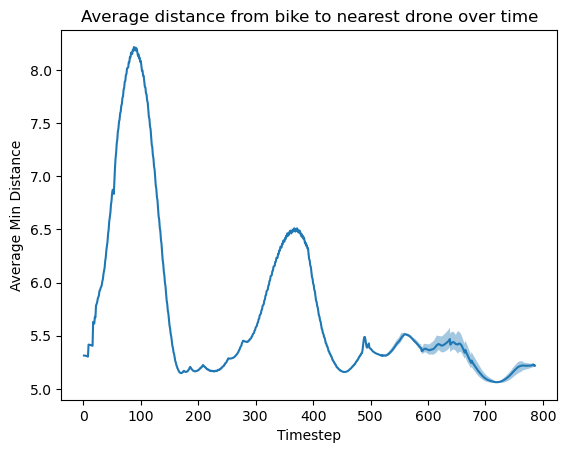

In [61]:
df = pd.read_csv("data/bike_data.csv")
avg_dist = df.groupby("Timestep")["min_distance"].agg(["mean", "min", "max"]).reset_index()

sns.lineplot(data=avg_dist, x="Timestep", y="mean")

plt.fill_between(
    avg_dist["Timestep"],
    avg_dist["min"],
    avg_dist["max"],
    alpha=0.4
)

plt.title("Average distance from bike to nearest drone over time")
plt.xlabel("Timestep")
plt.ylabel("Average Min Distance")
plt.show()

### Percentage of bikes in range of a drone


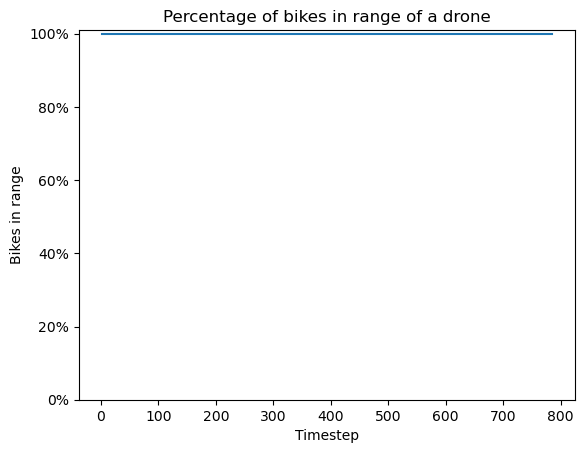

In [47]:
df = pd.read_csv("data/bike_data.csv")
percentage_per_time = (
    df.groupby("Timestep")["nearby_drones"]
    .apply(lambda x: (x > 0).mean() * 100)
    .reset_index(name="bikes_in_range_of_drones")
)

sns.lineplot(data=percentage_per_time, x="Timestep", y="bikes_in_range_of_drones")
plt.gca().yaxis.set_major_formatter(lambda x, _: f"{x:.0f}%")
plt.ylim(0, 101)
plt.title("Percentage of bikes in range of a drone")
plt.ylabel("Bikes in range")
plt.show()


### Collisions over time

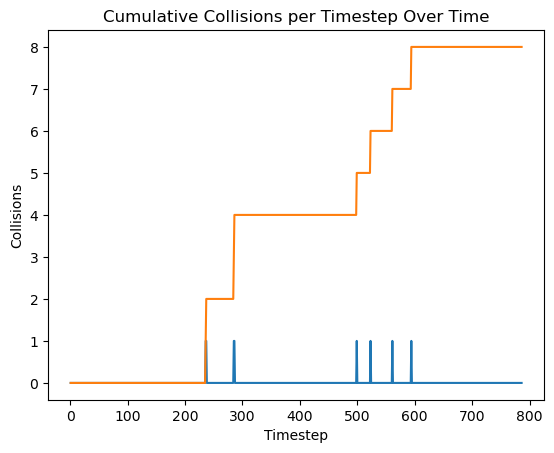

In [ ]:
df = pd.read_csv("data/drone_data.csv")
collisions_at_time = df.groupby("Timestep")["Collisions"].sum().reset_index()

#Each drone in a collision detects it, so we divide by 2
collisions_at_time["Collisions"] = collisions_at_time["Collisions"] / 2
collisions_at_time["Cumulative_collisions"] = collisions_at_time["Collisions"].cumsum()

sns.lineplot(data=collisions_at_time, x="Timestep", y="Collisions")

sns.lineplot(
    data=collisions_at_time, x="Timestep", y="Cumulative_collisions"
)

plt.title("Cumulative Collisions per Timestep Over Time")
plt.show()


### Average amount of bikes in range of a drone over time

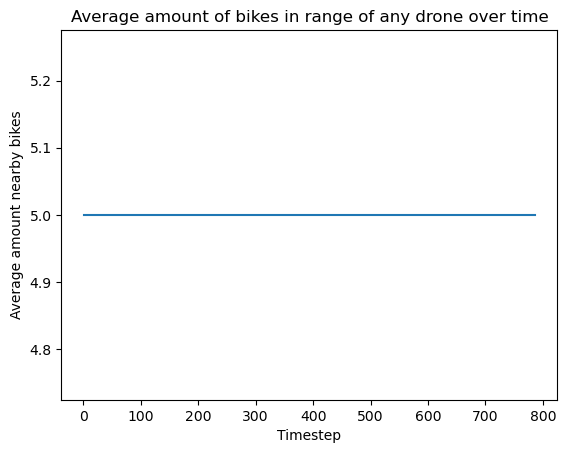

In [ ]:
df = pd.read_csv("data/drone_data.csv")
nearby_bikes_stats = df.groupby("Timestep")["nearby_bikes"].agg(["mean", "min", "max"]).reset_index()

sns.lineplot(data=nearby_bikes_stats, x="Timestep", y="mean")

plt.fill_between(
    avg_dist["Timestep"],
    avg_dist["min"],
    avg_dist["max"],
    alpha=0.4
)

plt.title("Average amount of bikes in range of any drone over time")
plt.ylabel("Average amount nearby bikes")
plt.show()